In [231]:
# Useful starting lines
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load the data

In [232]:
import datetime
from helpers import *

height, weight, gender = load_data(sub_sample=False, add_outlier=False)
x, mean_x, std_x = standardize(height)
y, tx = build_model_data(x, weight)

In [233]:
y.shape, tx.shape

((10000,), (10000, 2))

### NB: throughout this laboratory the data has the following format: 
  * there are **N = 10000** data entries
  * **y** represents the column vector containing weight information -- that which we wish to predict/the output (see also the first page of $\texttt{exercise02.pdf}$). Its **shape** is **(N,)**.
  * **tx** represents the matrix $\tilde{X}$ formed by laterally concatenating a column vector of 1s to the column vector of height information -- the input data (see also the first page of $\texttt{exercise02.pdf}$). Its **shape** is **(N,2)**.

# 1. Computing the Cost Function
Fill in the `compute_loss` function below:

In [234]:
def compute_loss(y, tx, w):
    """Calculate the loss using either MSE or MAE.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        w: numpy array of shape=(2,). The vector of model parameters.

    Returns:
        the value of the loss (a scalar), corresponding to the input parameters w.
    """
    # ***************************************************
    # INSERT YOUR CODE HERE
    # TODO: compute loss by MSE
    # ***************************************************

    sum = (1 / len(y)) * np.sum((y - tx.dot(w)) ** 2)
    return sum

In [235]:
print(compute_loss(y, tx, [73, 15]))

33.16944016130725


# 2. Grid Search

Fill in the function `grid_search()` below:

In [236]:
# from costs import *


def grid_search(y, tx, grid_w0, grid_w1):
    """Algorithm for grid search.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        grid_w0: numpy array of shape=(num_grid_pts_w0, ). A 1D array containing num_grid_pts_w0 values of parameter w0 to be tested in the grid search.
        grid_w1: numpy array of shape=(num_grid_pts_w1, ). A 1D array containing num_grid_pts_w1 values of parameter w1 to be tested in the grid search.

    Returns:
        losses: numpy array of shape=(num_grid_pts_w0, num_grid_pts_w1). A 2D array containing the loss value for each combination of w0 and w1
    """

    losses = np.zeros((len(grid_w0), len(grid_w1)))
    # ***************************************************
    # INSERT YOUR CODE HERE
    # TODO: compute loss for each combination of w0 and w1.
    # ***************************************************


    min = compute_loss(y, tx, [1, 2])

    for i in range(len(grid_w0)):
        for j in range(len(grid_w1)):
            losses[i][j] = compute_loss(y, tx, [grid_w0[i], grid_w1[j]])
    return losses

Let us play with the grid search demo now!

Grid Search: loss*=37.58708203904648, w0*=71.42857142857142, w1*=15.306122448979579, execution time=0.134 seconds


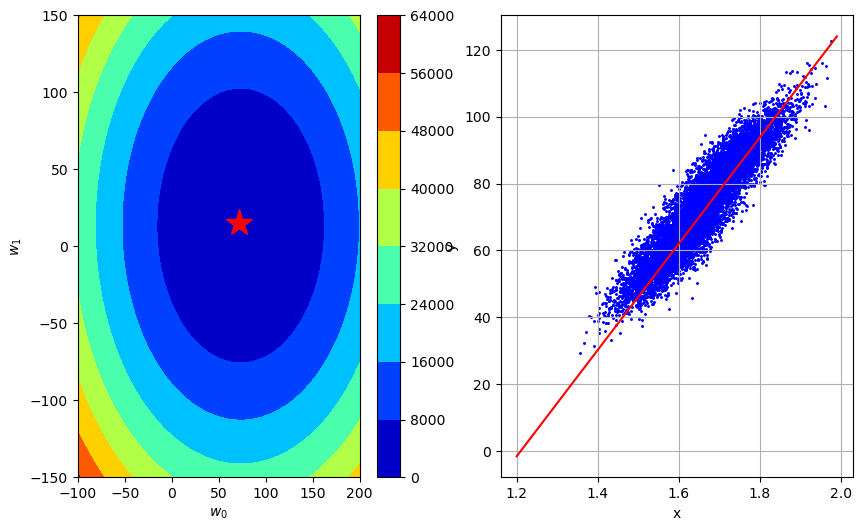

In [237]:
from grid_search import generate_w, get_best_parameters
from plots import grid_visualization

# Generate the grid of parameters to be swept
grid_w0, grid_w1 = generate_w(num_intervals=50)

# Start the grid search
start_time = datetime.datetime.now()
grid_losses = grid_search(y, tx, grid_w0, grid_w1)

# Select the best combinaison
loss_star, w0_star, w1_star = get_best_parameters(grid_w0, grid_w1, grid_losses)
end_time = datetime.datetime.now()
execution_time = (end_time - start_time).total_seconds()

# Print the results
print(
    "Grid Search: loss*={l}, w0*={w0}, w1*={w1}, execution time={t:.3f} seconds".format(
        l=loss_star, w0=w0_star, w1=w1_star, t=execution_time
    )
)

# Plot the results
fig = grid_visualization(grid_losses, grid_w0, grid_w1, mean_x, std_x, height, weight)
fig.set_size_inches(10.0, 6.0)
fig.savefig("grid_plot")  # Optional saving

# 3. Gradient Descent

Again, please fill in the functions `compute_gradient` below:

In [238]:
def compute_gradient(y, tx, w):
    """Computes the gradient at w.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        w: numpy array of shape=(2, ). The vector of model parameters.

    Returns:
        An numpy array of shape (2, ) (same shape as w), containing the gradient of the loss at w.
    """
    # ***************************************************
    # INSERT YOUR CODE HERE
    # TODO: compute gradient vector
    # ***************************************************

    gradient = (-1 / len(y)) * tx.T @ (y - tx.dot(w))

    return gradient

y1 = np.array([1, 2, 3])
tx1 = np.array([[1, 3],[1, 4],[1, 6]])

print(compute_gradient(y1, tx1, [2, 1]))

print(compute_gradient(y, tx, [100, 20]))

print(compute_gradient(y, tx, [50, 10]))

[ 4.33333333 19.33333333]
[26.706078    6.52028757]
[-23.293922    -3.47971243]


Please fill in the functions `gradient_descent` below:

In [239]:
def gradient_descent(y, tx, initial_w, max_iters, gamma):
    """The Gradient Descent (GD) algorithm.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        initial_w: numpy array of shape=(2, ). The initial guess (or the initialization) for the model parameters
        max_iters: a scalar denoting the total number of iterations of GD
        gamma: a scalar denoting the stepsize

    Returns:
        losses: a list of length max_iters containing the loss value (scalar) for each iteration of GD
        ws: a list of length max_iters + 1 containing the model parameters as numpy arrays of shape (2, ),
            for each iteration of GD (as well as the final weights)
    """
    # Define parameters to store w and loss
    ws = [initial_w]
    losses = []
    w = initial_w
    for n_iter in range(max_iters):

        w = w - gamma * compute_gradient(y, tx, w)
        loss = compute_loss(y, tx, w)

        # store w and loss
        ws.append(w)
        losses.append(loss)
        print(
            "GD iter. {bi}/{ti}: loss={l}, w0={w0}, w1={w1}".format(
                bi=n_iter, ti=max_iters - 1, l=loss, w0=w[0], w1=w[1]
            )
        )

    return losses, ws

Test your gradient descent function through gradient descent demo shown below:

In [240]:
# from gradient_descent import *
from plots import gradient_descent_visualization

# Define the parameters of the algorithm.
max_iters = 50
gamma = 0.1

# Initialization
w_initial = np.array([100, 10])

# Start gradient descent.
start_time = datetime.datetime.now()
gd_losses, gd_ws = gradient_descent(y, tx, w_initial, max_iters, gamma)
end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("GD: execution time={t:.3f} seconds".format(t=exection_time))

GD iter. 0/49: loss=618.2834062721446, w0=97.32939220021052, w1=10.34797124349891
GD iter. 1/49: loss=506.6561964705916, w0=94.92584518039997, w1=10.66114536264793
GD iter. 2/49: loss=416.23815653133477, w0=92.7626528625705, w1=10.943002069882045
GD iter. 3/49: loss=342.99954418053665, w0=90.81577977652398, w1=11.196673106392748
GD iter. 4/49: loss=283.6762681763898, w0=89.0635939990821, w1=11.424977039252381
GD iter. 5/49: loss=235.62441461303086, w0=87.48662679938441, w1=11.63045057882605
GD iter. 6/49: loss=196.7024132267101, w0=86.06735631965648, w1=11.81537676444235
GD iter. 7/49: loss=165.17559210379036, w0=84.79001288790136, w1=11.981810331497021
GD iter. 8/49: loss=139.6388669942255, w0=83.64040379932175, w1=12.131600541846227
GD iter. 9/49: loss=118.9541196554778, w0=82.60575561960009, w1=12.266411731160511
GD iter. 10/49: loss=102.19947431109219, w0=81.6745722578506, w1=12.387741801543367
GD iter. 11/49: loss=88.62821158213991, w0=80.83650723227606, w1=12.496938864887936
GD i

In [241]:
# Time Visualization
from ipywidgets import IntSlider, interact


def plot_figure(n_iter):
    fig = gradient_descent_visualization(
        gd_losses,
        gd_ws,
        grid_losses,
        grid_w0,
        grid_w1,
        mean_x,
        std_x,
        height,
        weight,
        n_iter,
    )
    fig.set_size_inches(10.0, 6.0)


interact(plot_figure, n_iter=IntSlider(min=1, max=len(gd_ws)))

interactive(children=(IntSlider(value=1, description='n_iter', max=51, min=1), Output()), _dom_classes=('widge…

<function __main__.plot_figure(n_iter)>

# 4. Stochastic gradient descent

In [242]:
def compute_stoch_gradient(y, tx, w):
    """Compute a stochastic gradient at w from a data sample batch of size B, where B < N, and their corresponding labels.

    Args:
        y: numpy array of shape=(B, )
        tx: numpy array of shape=(B,2)
        w: numpy array of shape=(2, ). The vector of model parameters.

    Returns:
        A numpy array of shape (2, ) (same shape as w), containing the stochastic gradient of the loss at w.
    """

    n = np.random.randint(0, len(y))
    Ln = - (tx[n][:]).T * (y[n] - tx[n] @ w)
    return Ln



def stochastic_gradient_descent(y, tx, initial_w, batch_size, max_iters, gamma):
    """The Stochastic Gradient Descent algorithm (SGD).

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        initial_w: numpy array of shape=(2, ). The initial guess (or the initialization) for the model parameters
        batch_size: a scalar denoting the number of data points in a mini-batch used for computing the stochastic gradient
        max_iters: a scalar denoting the total number of iterations of SGD
        gamma: a scalar denoting the stepsize

    Returns:
        losses: a list of length max_iters containing the loss value (scalar) for each iteration of SGD
        ws: a list of length max_iters containing the model parameters as numpy arrays of shape (2, ), for each iteration of SGD
    """

    # Define parameters to store w and loss
    ws = [initial_w]
    losses = []
    w = initial_w

    for n_iter in range(max_iters):

        w = w - gamma * compute_stoch_gradient(y, tx, w)
        loss = compute_loss(y, tx, w)

        ws.append(w)
        losses.append(loss)
        print(
            "SGD iter. {bi}/{ti}: loss={l}, w0={w0}, w1={w1}".format(
                bi=n_iter, ti=max_iters - 1, l=loss, w0=w[0], w1=w[1]
            )
        )
    return losses, ws

In [243]:
# from stochastic_gradient_descent import *

# Define the parameters of the algorithm.
max_iters = 50
gamma = 0.1
batch_size = 1

# Initialization
w_initial = np.array([0, 0])

# Start SGD.
start_time = datetime.datetime.now()
sgd_losses, sgd_ws = stochastic_gradient_descent(
    y, tx, w_initial, batch_size, max_iters, gamma
)
end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("SGD: execution time={t:.3f} seconds".format(t=exection_time))

SGD iter. 0/49: loss=4741.128709294857, w0=6.241842705645186, w1=-1.1618583679828949
SGD iter. 1/49: loss=4408.495373010845, w0=10.562981868372312, w1=-7.557225251166928
SGD iter. 2/49: loss=4237.060616050482, w0=13.641287679577554, w1=-11.973225680199615
SGD iter. 3/49: loss=4065.9267752957094, w0=16.56172099779624, w1=-15.09671786630541
SGD iter. 4/49: loss=3040.498794890262, w0=23.792637646869267, w1=-10.170866127377684
SGD iter. 5/49: loss=2890.5106828215416, w0=26.59917877390992, w1=-12.584436542807975
SGD iter. 6/49: loss=2295.3592288252944, w0=32.06063295860987, w1=-10.277461802348322
SGD iter. 7/49: loss=2289.920828124788, w0=32.56539356536454, w1=-11.022043089151236
SGD iter. 8/49: loss=2033.9529752924018, w0=36.081793847999926, w1=-11.388715697830106
SGD iter. 9/49: loss=1989.5483027129737, w0=37.696186276496654, w1=-12.818153223369066
SGD iter. 10/49: loss=1991.5650573461123, w0=37.866050978206175, w1=-13.084534897138246
SGD iter. 11/49: loss=1890.3896444926636, w0=40.391870

In [244]:
# Time Visualization
from ipywidgets import IntSlider, interact


def plot_figure(n_iter):
    fig = gradient_descent_visualization(
        sgd_losses,
        sgd_ws,
        grid_losses,
        grid_w0,
        grid_w1,
        mean_x,
        std_x,
        height,
        weight,
        n_iter,
    )
    fig.set_size_inches(10.0, 6.0)


interact(plot_figure, n_iter=IntSlider(min=1, max=len(sgd_ws)))

interactive(children=(IntSlider(value=1, description='n_iter', max=51, min=1), Output()), _dom_classes=('widge…

<function __main__.plot_figure(n_iter)>

# 5. Effect of Outliers and MAE Cost Function

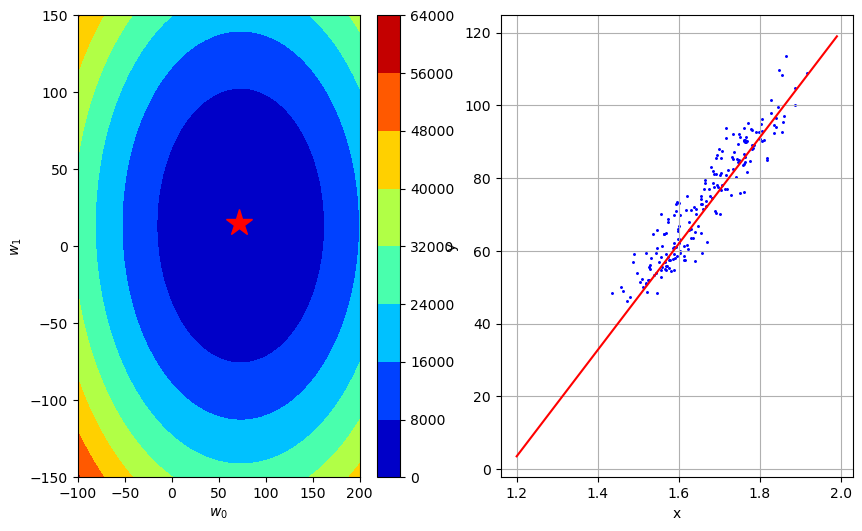

In [245]:
import datetime
from helpers import *

# ***************************************************
# INSERT YOUR CODE HERE
# TODO: reload the data by subsampling first, then by subsampling and adding outliers
# ***************************************************
height, weight, gender = load_data(sub_sample=True, add_outlier=False)
x, mean_x, std_x = standardize(height)
y, tx = build_model_data(x, weight)

fig = grid_visualization(grid_losses, grid_w0, grid_w1, mean_x, std_x, height, weight)
fig.set_size_inches(10.0, 6.0)
fig.savefig("grid_plot")  # Optional saving




In [246]:
y.shape, tx.shape

((200,), (200, 2))

In [247]:
sgd_losses, sgd_ws = stochastic_gradient_descent(
    y, tx, w_initial, batch_size, max_iters, gamma
)
def plot_figure(n_iter):
    fig = gradient_descent_visualization(
        sgd_losses,
        sgd_ws,
        grid_losses,
        grid_w0,
        grid_w1,
        mean_x,
        std_x,
        height,
        weight,
        n_iter,
    )
    fig.set_size_inches(10.0, 6.0)


interact(plot_figure, n_iter=IntSlider(min=1, max=len(sgd_ws)))

SGD iter. 0/49: loss=4179.0951861701, w0=9.341726092141007, w1=10.170595783301437
SGD iter. 1/49: loss=3613.4560195877416, w0=15.149252864072322, w1=1.5952713069301154
SGD iter. 2/49: loss=3103.4987001247437, w0=20.039444030195735, w1=0.19212789361942262
SGD iter. 3/49: loss=2584.8943600682733, w0=25.177117892535456, w1=-0.005506616887723803
SGD iter. 4/49: loss=2464.5904633881555, w0=28.565897479586013, w1=-5.68181084138036
SGD iter. 5/49: loss=2105.211184208784, w0=32.82833030411585, w1=-5.84577683988808
SGD iter. 6/49: loss=1040.3845357432672, w0=41.825120409917716, w1=15.660080070483938
SGD iter. 7/49: loss=890.3692671368652, w0=44.269943484051225, w1=15.443193707261129
SGD iter. 8/49: loss=787.7482599310893, w0=46.54216826212054, w1=19.632025742194646
SGD iter. 9/49: loss=719.3581039034622, w0=48.44721153412998, w1=22.077279743145727
SGD iter. 10/49: loss=674.1884392539796, w0=50.265898295655205, w1=24.52130730015172
SGD iter. 11/49: loss=451.7374112709549, w0=54.05636132587551, w

interactive(children=(IntSlider(value=1, description='n_iter', max=51, min=1), Output()), _dom_classes=('widge…

<function __main__.plot_figure(n_iter)>

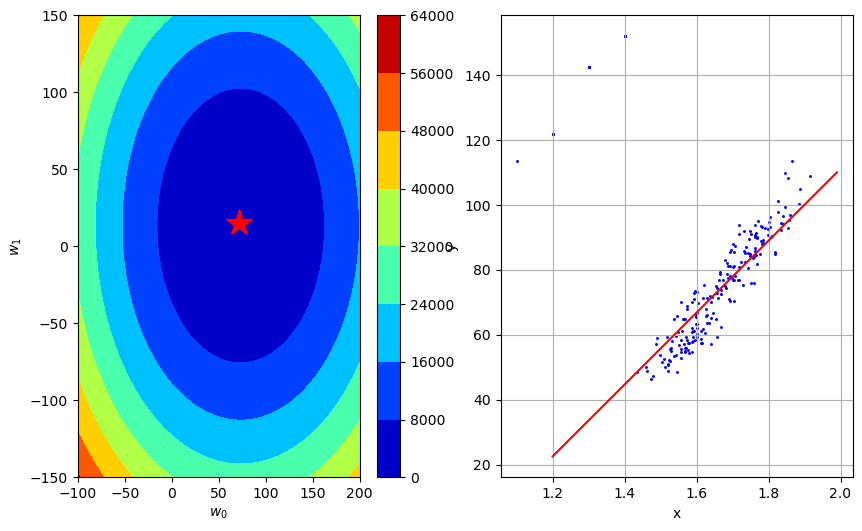

In [248]:
height, weight, gender = load_data(sub_sample=True, add_outlier=True)
x, mean_x, std_x = standardize(height)
y, tx = build_model_data(x, weight)

fig = grid_visualization(grid_losses, grid_w0, grid_w1, mean_x, std_x, height, weight)
fig.set_size_inches(10.0, 6.0)
fig.savefig("grid_plot")  # Optional saving

In [249]:
from plots import gradient_descent_visualization

# Define the parameters of the algorithm.
max_iters = 50
gamma = 0.7

# Initialization
w_initial = np.array([0, 0])

# Start gradient descent.
start_time = datetime.datetime.now()


sgd_losses, sgd_ws = stochastic_gradient_descent(
    y, tx, w_initial, batch_size, max_iters, gamma
)


end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("GD: execution time={t:.3f} seconds".format(t=exection_time))

SGD iter. 0/49: loss=2179.917426929296, w0=45.30731052798794, w1=-25.21049618601114
SGD iter. 1/49: loss=2435.9593365589662, w0=37.85937884894824, w1=-19.179273844896468
SGD iter. 2/49: loss=2133.638768080106, w0=43.564992420281456, w1=-21.91259279392999
SGD iter. 3/49: loss=890.2400290433177, w0=69.26097404818978, w1=-18.078084197448337
SGD iter. 4/49: loss=794.7044126986326, w0=95.17388698651604, w1=5.396118058244539
SGD iter. 5/49: loss=523.784779667054, w0=81.78102702085573, w1=7.514584891046658
SGD iter. 6/49: loss=492.7218390661034, w0=79.93968427653208, w1=5.906197068202104
SGD iter. 7/49: loss=19559.89258188352, w0=122.44293907721601, w1=-129.7632658184392
SGD iter. 8/49: loss=19556.777150419068, w0=120.9068642269356, w1=-130.26977412182367
SGD iter. 9/49: loss=23252.905494862818, w0=-47.04029506761324, w1=86.26272266033126
SGD iter. 10/49: loss=1785.4006516054365, w0=57.01328253044298, w1=30.98962550901524
SGD iter. 11/49: loss=1570.013272197026, w0=68.87430533164718, w1=33.07

In [250]:
# Time Visualization
from ipywidgets import IntSlider, interact


def plot_figure(n_iter):
    fig = gradient_descent_visualization(
        gd_losses,
        gd_ws,
        grid_losses,
        grid_w0,
        grid_w1,
        mean_x,
        std_x,
        height,
        weight,
        n_iter,
    )
    fig.set_size_inches(10.0, 6.0)


interact(plot_figure, n_iter=IntSlider(min=1, max=len(gd_ws)))

interactive(children=(IntSlider(value=1, description='n_iter', max=51, min=1), Output()), _dom_classes=('widge…

<function __main__.plot_figure(n_iter)>

# 6. Subgradient descent

In [251]:
def compute_loss_MAE(y, tx, w):
    """Calculate the loss using either MSE or MAE.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        w: numpy array of shape=(2,). The vector of model parameters.

    Returns:
        the value of the loss (a scalar), corresponding to the input parameters w.
    """


    sum = (1 / len(y)) * np.sum(np.abs((y - tx.dot(w))))
    return sum

In [252]:
def compute_subgradient_mae(y, tx, w):
    """Compute a subgradient of the MAE at w.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        w: numpy array of shape=(2, ). The vector of model parameters.

    Returns:
        A numpy array of shape (2, ) (same shape as w), containing the subgradient of the MAE at w.
    """
    e = y - tx.dot(w)
    sign = np.sign(e)

    if np.any(np.abs(e) == 0.000):
        print("\n")
        print(f"Warning: y - tx.dot(w) is very small: {e}")
        print("\n")
            
    L_mae = -(1/len(y)) * tx.T @ sign
    return L_mae

In [253]:
def subgradient_descent(y, tx, initial_w, max_iters, gamma):
    """The SubGradient Descent (SubGD) algorithm.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        initial_w: numpy array of shape=(2, ). The initial guess (or the initialization) for the model parameters
        max_iters: a scalar denoting the total number of iterations of GD
        gamma: a scalar denoting the stepsize

    Returns:
        losses: a list of length max_iters containing the loss value (scalar) for each iteration of SubGD
        ws: a list of length max_iters containing the model parameters as numpy arrays of shape (2, ), for each iteration of SubGD
    """
    # Define parameters to store w and loss
    ws = [initial_w]
    losses = []
    w = initial_w
    for n_iter in range(max_iters):
        loss = compute_loss_MAE(y, tx, w)
        g = compute_subgradient_mae(y, tx, w)

        w = w - gamma * g

        ws.append(w)
        losses.append(loss)
        print(
            "SubGD iter. {bi}/{ti}: loss={l}, w0={w0}, w1={w1}".format(
                bi=n_iter, ti=max_iters - 1, l=loss, w0=w[0], w1=w[1]
            )
        )

    return losses, ws

In [254]:
# Define the parameters of the algorithm.
max_iters = 500
gamma = 0.7
batch_size = 1

# Initialization
w_initial = np.array([0, 0])

# Start SubSGD.
start_time = datetime.datetime.now()
subgd_losses, subgd_ws = subgradient_descent(y, tx, w_initial, max_iters, gamma)
end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("SubGD: execution time={t:.3f} seconds".format(t=exection_time))

SubGD iter. 0/499: loss=77.48690244885744, w0=0.6999999999999974, w1=4.043640422501937e-16
SubGD iter. 1/499: loss=76.78690244885743, w0=1.3999999999999948, w1=8.087280845003874e-16
SubGD iter. 2/499: loss=76.08690244885743, w0=2.099999999999992, w1=1.2130921267505811e-15
SubGD iter. 3/499: loss=75.38690244885743, w0=2.7999999999999896, w1=1.6174561690007749e-15
SubGD iter. 4/499: loss=74.68690244885744, w0=3.499999999999987, w1=2.0218202112509687e-15
SubGD iter. 5/499: loss=73.98690244885745, w0=4.199999999999984, w1=2.4261842535011622e-15
SubGD iter. 6/499: loss=73.28690244885743, w0=4.899999999999982, w1=2.830548295751356e-15
SubGD iter. 7/499: loss=72.58690244885746, w0=5.599999999999979, w1=3.2349123380015494e-15
SubGD iter. 8/499: loss=71.88690244885744, w0=6.299999999999977, w1=3.639276380251743e-15
SubGD iter. 9/499: loss=71.18690244885745, w0=6.999999999999974, w1=4.0436404225019365e-15
SubGD iter. 10/499: loss=70.48690244885745, w0=7.699999999999972, w1=4.44800446475213e-15
S

In [255]:
from ipywidgets import IntSlider, interact


def plot_figure(n_iter):
    fig = gradient_descent_visualization(
        subgd_losses,
        subgd_ws,
        grid_losses,
        grid_w0,
        grid_w1,
        mean_x,
        std_x,
        height,
        weight,
        n_iter,
    )
    fig.set_size_inches(10.0, 6.0)


interact(plot_figure, n_iter=IntSlider(min=1, max=len(subgd_ws)))

interactive(children=(IntSlider(value=1, description='n_iter', max=501, min=1), Output()), _dom_classes=('widg…

<function __main__.plot_figure(n_iter)>

# Stochastic Subgradient Descent

**NB** for the computation of the subgradient you can reuse the `compute_subgradient` method that you implemented above, just making sure that you pass in a minibatch as opposed to the full data.

In [256]:
def compute_sto_subgradient_mae(y, tx, w):
    """Compute a subgradient of the MAE at w.

    Args:
        y: numpy array of shape=(N, )
        tx: numpy array of shape=(N,2)
        w: numpy array of shape=(2, ). The vector of model parameters.

    Returns:
        A numpy array of shape (2, ) (same shape as w), containing the subgradient of the MAE at w.
    """

    n = np.random.randint(0, len(y))
    sign = np.sign(y[n] - tx[n].dot(w))
    gn = -(tx[n][:]).T * sign
    return gn

In [257]:
def stochastic_subgradient_descent(y, tx, initial_w, batch_size, max_iters, gamma):
    """Compute a stochastic subgradient at w from a data sample batch of size B, where B < N, and their corresponding labels.

    Args:
        y: numpy array of shape=(B, )
        tx: numpy array of shape=(B,2)
        initial_w: numpy array of shape=(2, ). The initial guess (or the initialization) for the model parameters
        batch_size: a scalar denoting the number of data points in a mini-batch used for computing the stochastic subgradient
        max_iters: a scalar denoting the total number of iterations of SubSGD
        gamma: a scalar denoting the stepsize

    Returns:
        losses: a list of length max_iters containing the loss value (scalar) for each iteration of SubSGD
        ws: a list of length max_iters containing the model parameters as numpy arrays of shape (2, ), for each iteration of SubSGD
    """

    # Define parameters to store w and loss
    ws = [initial_w]
    losses = []
    w = initial_w

    for n_iter in range(max_iters):

        loss = compute_loss_MAE(y, tx, w)
        g = compute_sto_subgradient_mae(y, tx, w)
        
        w = w - gamma * g
        
        ws.append(w)
        losses.append(loss)

        print(
            "SubSGD iter. {bi}/{ti}: loss={l}, w0={w0}, w1={w1}".format(
                bi=n_iter, ti=max_iters - 1, l=loss, w0=w[0], w1=w[1]
            )
        )
    return losses, ws

In [258]:
# Define the parameters of the algorithm.
max_iters = 500
gamma = 0.7
batch_size = 1

# Initialization
w_initial = np.array([0, 0])

# Start SubSGD.
start_time = datetime.datetime.now()
subsgd_losses, subsgd_ws = stochastic_subgradient_descent(
    y, tx, w_initial, batch_size, max_iters, gamma
)
end_time = datetime.datetime.now()

# Print result
exection_time = (end_time - start_time).total_seconds()
print("SubSGD: execution time={t:.3f} seconds".format(t=exection_time))

SubSGD iter. 0/499: loss=77.48690244885744, w0=0.7, w1=0.2564598594834648
SubSGD iter. 1/499: loss=76.78690244885743, w0=1.4, w1=0.8878801084530044
SubSGD iter. 2/499: loss=76.08690244885742, w0=2.0999999999999996, w1=0.6241267720910739
SubSGD iter. 3/499: loss=75.38690244885743, w0=2.8, w1=0.43331638334865485
SubSGD iter. 4/499: loss=74.68690244885744, w0=3.5, w1=1.375183831314144
SubSGD iter. 5/499: loss=73.98690244885744, w0=4.2, w1=1.5623549240621095
SubSGD iter. 6/499: loss=73.28690244885743, w0=4.9, w1=1.9425474660787065
SubSGD iter. 7/499: loss=72.58690244885743, w0=5.6000000000000005, w1=2.576669211406747
SubSGD iter. 8/499: loss=71.88690244885743, w0=6.300000000000001, w1=3.4633183492764505
SubSGD iter. 9/499: loss=71.18690244885741, w0=7.000000000000001, w1=3.0334785951477348
SubSGD iter. 10/499: loss=70.48690244885744, w0=7.700000000000001, w1=3.1472271434837893
SubSGD iter. 11/499: loss=69.78690244885742, w0=8.4, w1=3.367204947588276
SubSGD iter. 12/499: loss=69.08690244885

In [259]:
from ipywidgets import IntSlider, interact


def plot_figure(n_iter):
    fig = gradient_descent_visualization(
        subsgd_losses,
        subsgd_ws,
        grid_losses,
        grid_w0,
        grid_w1,
        mean_x,
        std_x,
        height,
        weight,
        n_iter,
    )
    fig.set_size_inches(10.0, 6.0)


interact(plot_figure, n_iter=IntSlider(min=1, max=len(subsgd_ws)))

interactive(children=(IntSlider(value=1, description='n_iter', max=501, min=1), Output()), _dom_classes=('widg…

<function __main__.plot_figure(n_iter)>